### knowledge

卷积层保留空间信息

卷积层要求输入输出的是四维张量(B, C, W, H)，全连接层的输入输出是二位张良(B, Input_feature)

输入为 n * w_in * h_in，即通道为 n, 宽和长分别为 w_in 和 h_i，经过 m 个卷积核(这些卷积核构成四维张量 m * n * kernel_size_w * kernel_size_h)，输出变为 m * w_out * h_out

对于卷积层（以 `Conv2d` 为例），输入与输出形状的变换公式如下：

**1. 基本公式（单维度）**

设：
- 输入尺寸： $ H_{\text{in}} \times W_{\text{in}} $
- 输出尺寸：$ H_{\text{out}} \times W_{\text{out}} $
- 卷积核大小：$ k_h \times k_w $
- 填充（padding）：$ p_h \times p_w $
- 步长（stride）：$ s_h \times s_w $
- 扩张（dilation）：$ d_h \times d_w $（默认 1）

则输出尺寸为：
$$
H_{\text{out}} = \left\lfloor \frac{H_{\text{in}} + 2p_h - d_h \times (k_h - 1) - 1}{s_h} + 1 \right\rfloor
$$
$$
W_{\text{out}} = \left\lfloor \frac{W_{\text{in}} + 2p_w - d_w \times (k_w - 1) - 1}{s_w} + 1 \right\rfloor
$$

其中 $\lfloor \cdot \rfloor$ 表示向下取整（PyTorch 中默认向下取整）

In [1]:
# Convolutional Layer
import torch

in_channels, out_channels = 5, 10
width, height = 100, 100
kernel_size = 3
batch_size = 1

# 生成输入数据，数据形状为(batch_size, in_channels, width, height), randn表示随机生成正态分布的数据
input = torch.randn(batch_size, in_channels, width, height)

# 生成卷积核，形状为(out_channels, in_channels, kernel_size, kernel_size)
# 参数顺序为(输入通道数, 输出通道数, 卷积核大小)，但卷积核的形状为(out_channels, in_channels, kernel_size, kernel_size)
conv_layer = torch.nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size)

# 对输入数据进行卷积操作得到输出数据
output = conv_layer(input)

print(input.shape)
print(output.shape)
print(conv_layer.weight.shape)

torch.Size([1, 5, 100, 100])
torch.Size([1, 10, 98, 98])
torch.Size([10, 5, 3, 3])


In [2]:
# padding
 
input = [3, 4, 6, 5, 7,
         2, 4, 6, 8, 2,
         1, 6, 7, 8, 4,
         9, 7, 4, 6, 2,
         3, 7, 5, 4, 1]
 
"""
input.shape = (1, 1, 5, 5)
卷积核：输入通道， 输出通道， 卷积核3*3, padding = 1, 不设置偏置
重写卷积核参数
数据训练
"""
input = torch.Tensor(input).view(1, 1, 5, 5)    # 将输入数据转换为四维张量
 
conv_layer = torch.nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
 
kernel = torch.Tensor([1, 2, 3, 4, 5, 6, 7, 8, 9]).view(1, 1, 3, 3)    # 构建卷积核
conv_layer.weight.data = kernel.data    # 将卷积核的参数值赋值给卷积层
 
output = conv_layer(input)
print(output)

tensor([[[[ 91., 168., 224., 215., 127.],
          [114., 211., 295., 262., 149.],
          [192., 259., 282., 214., 122.],
          [194., 251., 253., 169.,  86.],
          [ 96., 112., 110.,  68.,  31.]]]], grad_fn=<ConvolutionBackward0>)


In [3]:
"""
数据转换: batch, channel, width, height
卷积核2*2, MaxPool2d函数, 2*2的最大池化层
搭建模型
"""
input = [3, 4, 6, 5,
         2, 4, 6, 8,
         1, 6, 7, 8,
         9, 7, 4, 6,
         ]
input = torch.Tensor(input).view(1, 1, 4, 4)
 
maxpooling_layer = torch.nn.MaxPool2d(kernel_size=2)
 
output = maxpooling_layer(input)
print(output)

tensor([[[[4., 8.],
          [9., 8.]]]])


### practice

In [11]:
# 构建依赖
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import time
import random

In [12]:
# data prepare, mnist dataset
batch_size = 64
transform = transforms.Compose([transforms.ToTensor(), 
                                transforms.Normalize((0.1307,), (0.3081,))])
# 训练集
train_dataset = datasets.MNIST(root='./dataset/mnist', train=True, download=False, transform=transform)
# 测试集
test_dataset = datasets.MNIST(root='./dataset/mnist', train=False, download=False, transform=transform)
# 数据加载器
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"size of train_loader: {train_loader.dataset.data.size()}")
print(f"size of test_loader: {test_loader.dataset.data.size()}")

size of train_loader: torch.Size([60000, 28, 28])
size of test_loader: torch.Size([10000, 28, 28])


In [13]:
# model design
class Net(torch.nn.Module):
    def __init__(self):
        '''
        初始化网络结构, 网络层包含
        输入层, 卷积层, relu激活, 池化层, 全连接层
        '''
        super(Net, self).__init__()    # 继承父类
        self.conv1 = torch.nn.Conv2d(1, 10, kernel_size=5)    # 输入通道为1, 输出通道为10, 卷积核大小为5
        self.conv2 = torch.nn.Conv2d(10, 20, kernel_size=5)
        self.pooling = torch.nn.MaxPool2d(2)    # 最大池化层, 池化核大小为2
        self.fc = torch.nn.Linear(320, 10)     # 为什么是320? 因为输入为28*28的图像, 经过两次卷积和池化后, 变为20*4*4, 展平后为320

    def forward(self, x):
        batch_size = x.size(0)
        x = self.pooling(F.relu(self.conv1(x)))
        x = self.pooling(F.relu(self.conv2(x)))
        x = x.view(batch_size, -1)    # 展平后，全连接层的输入特征维度为320
        x = self.fc(x)
        return x

model = Net()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Net(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=320, out_features=10, bias=True)
)

In [14]:
# loss and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)

In [15]:
# train cycle
def train(epoch):
    model.train()
    running_loss = 0.0    # 用于每200个batch打印
    epoch_loss = 0.0      # 用于记录整个epoch平均loss
    num_batches = 0
    train_correct = 0
    train_total = 0

    for batch_idx, data in enumerate(train_loader, 0):
        '''
        batch_idx 是当前批次索引, data 是当前批次的数据和标签
        (train_loader, 0) 表示从train_loader中获取数据, 从0开始计数
        '''
        inputs, labels = data    # 获取当前循环的索引批次对应的输入数据和标签
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()    # 每一次循环开始时，先进行梯度清零

        outputs = model(inputs)    # 将输入数据传入模型Net，得到输出
        loss = criterion(outputs, labels)    # 损失函数计算
        loss.backward()    # 计算完损失函数后，进行反向传播, 计算梯度
        optimizer.step()    # 计算完梯度后，进行参数更新

        running_loss += loss.item()    # 损失值累加到running_loss中
        epoch_loss += loss.item()
        num_batches += 1

        _, predicted = torch.max(outputs.data, dim=1)
        train_total += labels.size(0)    # 获取标签的数量作为训练的总数量
        train_correct += (predicted == labels).sum().item()

        # 每200个批次打印一次损失，查看依次训练的损失
        if batch_idx % 200 == 199:
            print(f"[epoch {epoch + 1}, batch {batch_idx + 1}] loss: {running_loss / 200}")
            running_loss = 0.0

    avg_train_loss = epoch_loss / num_batches
    train_losses.append(avg_train_loss)
    train_accs.append(100 * train_correct / train_total)

In [16]:
# test
def test():
    '''
    return: 预测结果
    '''
    model.eval()
    correct = 0.0
    total = 0.0
    test_loss = 0.0
    num_batches = 0    # 记录测试集的批次数量

    with torch.no_grad():    # 推理阶段不需要计算梯度
        for data in test_loader:    # 获取测试集中的数据，数据由28*28的灰度图像和对应的标签组成
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            test_loss += loss.item()
            num_batches += 1

            # 获取输出中最大概率的索引
            # dim = 1 沿着列的方向取最大值，即按行取最大值，即从第一行开始，取每一行的所有列中列的最大值
            # 返回最大值的索引和最大值
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)    # 获取标签的数量
            correct += (predicted == labels).sum().item()    # 计算预测正确的数量

    avg_test_loss = test_loss / num_batches
    avg_test_acc = 100 * correct / total
    test_losses.append(avg_test_loss)
    test_accs.append(avg_test_acc)
    print(f"Accuracy of the network on the 10000 test images: {avg_test_acc}%")

[epoch 1, batch 200] loss: 0.8207007328420878
[epoch 1, batch 400] loss: 0.27344070076942445
[epoch 1, batch 600] loss: 0.18422196241095662
[epoch 1, batch 800] loss: 0.1528386120032519
Accuracy of the network on the 10000 test images: 96.21%
[epoch 2, batch 200] loss: 0.1311654736008495
[epoch 2, batch 400] loss: 0.10383731762412936
[epoch 2, batch 600] loss: 0.10126818161457778
[epoch 2, batch 800] loss: 0.09600422517396509
Accuracy of the network on the 10000 test images: 97.72%
[epoch 3, batch 200] loss: 0.08036196939181536
[epoch 3, batch 400] loss: 0.08109478586819023
[epoch 3, batch 600] loss: 0.07672623473918065
[epoch 3, batch 800] loss: 0.07217233437579125
Accuracy of the network on the 10000 test images: 98.03%
[epoch 4, batch 200] loss: 0.06985345557332039
[epoch 4, batch 400] loss: 0.05945928216446191
[epoch 4, batch 600] loss: 0.06812730837846175
[epoch 4, batch 800] loss: 0.06716584519715979
Accuracy of the network on the 10000 test images: 98.23%
[epoch 5, batch 200] lo

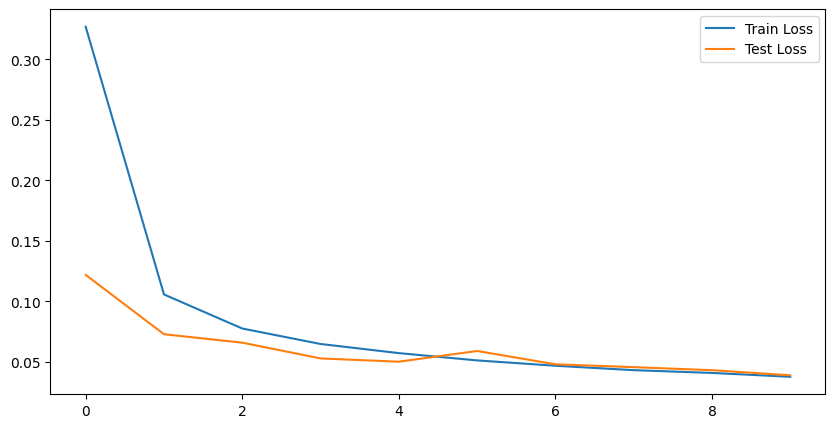

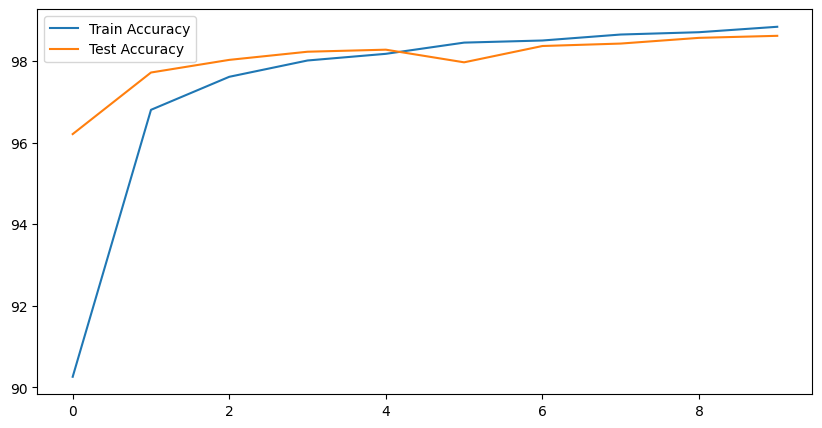

In [17]:
# 开始训练和测试，以及loss曲线和准确率曲线的可视化
if __name__ == "__main__":
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(10):
        train(epoch)
        test()

    # 可视化loss曲线
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.legend()
    plt.show()

    # 可视化准确率曲线
    plt.figure(figsize=(10, 5))
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(test_accs, label='Test Accuracy')
    plt.legend()
    plt.show()